# Setup

In [109]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
import yaml

with open(f"../config/plotting.default.yaml") as f:
    pypsa_config = yaml.safe_load(f)

with open(f"minerals_config.yaml") as f:
    techs_map = yaml.safe_load(f)

tech_colors = pypsa_config["plotting"]["tech_colors"]
nice_names = pypsa_config["plotting"]["nice_names"]

minerals = ['Aluminium', 'Cobalt', 'Copper', 'Dysprosium', 'Gallium',  'Graphite', 'Indium', 'Lithium', 'Manganese', 'Neodymium', 'Nickel', 'Praseodymium', 'Selenium', 'Silver', 'Tellurium', 'Vanadium', 'Zinc', 'Silicon', 'Chromium', 'Platinum', 'Palladium']
rare_earths = ['Neodymium', 'Praseodymium', 'Dysprosium']



In [22]:
techs_map

{'technology_map': {'Offshore Wind (AC)': 'wind power plant construction, 2MW, offshore, moving parts',
  'Offshore Wind (DC)': 'wind power plant construction, 2MW, offshore, moving parts',
  'Offshore Wind (Floating)': 'wind power plant construction, 2MW, offshore, moving parts',
  'Onshore Wind': 'wind turbine construction, 4.5MW, onshore',
  'Solar': 'photovoltaic plant construction, 570kWp, multi-Si, on open ground',
  'solar rooftop': 'photovoltaic slanted-roof installation, 3kWp, single-Si, panel, mounted, on roof',
  'solar thermal': None,
  'solar-hsat': None,
  'Run of River': None,
  'Reservoir & Dam': 'hydropower plant construction, reservoir, non-alpine regions',
  'Pumped Hydro Storage': None,
  'nuclear': 'nuclear power plant construction, boiling water reactor 1000MW',
  'Combined-Cycle Gas': 'gas power plant construction, combined cycle, 400MW electrical',
  'Open-Cycle Gas': 'gas turbine construction, 10MW electrical',
  'urban central solid biomass CHP': 'furnace prod

## Functions

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_mineral_usage(
    network_key,
    n,
    minerals,
    mineral_intensities=None,
    techs=None,
    capacity_col_name="capacity",
    verbose=False,
):
    """
    Return (df_merged, totals_series) for a given network in dict n.

    - df_merged: expanded capacities merged with intensity data. Contains mineral columns
                 multiplied by capacity (absolute mineral amount per row).
    - totals_series: Series indexed by mineral names with total mineral demand (units: same as conversion below).

    Behavior / assumptions:
    - Uses `n[network_key].statistics.expanded_capacity()` and expects capacity in column 0 (renamed to 'capacity').
    - If techs_map is provided, maps carriers via techs_map[lci_map_key] into column 'lci_technology'.
    - Tries to merge intensity data:
         * primary: merge mineral_intensities on left_on='lci_technology' or provided name -> right_on='Activity'
         * fallback: merge mineral_intensities_carrara on left_on='Other source name' -> right_on='Technology'
      Coalesces mineral columns preferring the primary source.
    - Returns totals in Mt if you divide by 1e9 (the code below returns totals_in_Mt).
    """

    # 1) expanded capacities
    df = pd.DataFrame(n[network_key].statistics.expanded_capacity().reset_index()).rename(columns={0: capacity_col_name})

    # optional: merge techs

    df = pd.merge(df, techs, left_on="carrier", right_on="PyPSA technology", how="inner")

    # 2) merge primary intensities (if provided)

    df = pd.merge(df, mineral_intensities, left_on="LCI name", right_on="Activity", how="inner")

    # 6) compute absolute mineral use per row: intensity * capacity
    # Note: intensity units must match this multiplication. Adjust conversion factor as needed.
    df = df.rename(columns={'capacity': 'carrier capacity'})
    df['Sub tech capacity'] = df['carrier capacity'].mul(df['Market share 2040'], axis=0)
    df[minerals] = df[minerals].mul(df['Sub tech capacity'], axis=0)



    # 7) aggregate totals (convert to Mt: divide by 1e9)
    totals_Mt = df[minerals].sum() / 1e9

    if verbose:
        print(f"Network {network_key}: merged rows {len(df)}; minerals found from sources: {', '.join([m for m in minerals if not df[m].isna().all()])}")

    return df, totals_Mt


def compare_networks(
    network_keys,
    n,
    minerals,
    techs,
    mineral_intensities=None,
    show_plot=True,
    figsize=(12,6),
):
    """
    Compute mineral totals for multiple network keys and return a DataFrame of totals (minerals x networks).
    Also plots a side-by-side bar chart comparing totals (Mt).
    """
    results = {}
    details = {}

    for k in network_keys:
        dfk, tot = compute_mineral_usage(
            k,
            n,
            minerals,
            mineral_intensities,
            techs 
        )
        results[k] = tot
        details[k] = dfk

    comparison = pd.DataFrame(results)

    if show_plot:
        # Optionally sort minerals by total across networks (largest minerals shown first in legend)
        comparison = comparison.loc[comparison.sum(axis=1).sort_values(ascending=False).index]

        # Transpose so rows = networks, columns = minerals and plot stacked bars
        stack_df = comparison.T  # index: networks, columns: minerals

        ax = stack_df.plot.bar(stacked=True, figsize=figsize, colormap='tab20')
        ax.set_ylabel("Mineral use [Mt]")
        ax.set_xlabel("Network")
        ax.set_title("Mineral demand breakdown per network")
        plt.xticks(rotation=0)
        ax.legend(title="Mineral", bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    return comparison, details

In [129]:
def stacked_barh_signed(
    data,
    ax,
    *,
    tech_colors=None,
    nice_names=None,
    y_label="Total",
    group_labels=None,
    annotate_thresh=0.03,
    annotate_decimals=0,
    title=None,
    group_bracket_height=0.15,  # Height above bar for group brackets
    bar_height=0.6,
    group_label_font_size=9,
    show_legend=True,
):
    """
    Plot horizontal stacked bars robust to negative values.

    Parameters
    ----------
    - data: pandas Series OR dict of Series
      - If Series with MultiIndex: single stacked bar with grouped bracket annotations
      - If Series with single index: single stacked bar (original behavior)
      - If dict: single stacked bar with grouped bracket annotations above
    - ax: matplotlib axis
    - tech_colors: dict carrier -> color (fallback '#888888')
    - nice_names: dict carrier -> pretty label
    - y_label: str, text for the y-axis label
    - group_labels: dict {group_key: label}, nice labels for group annotations (for dict/MultiIndex data)
    - annotate_thresh: fraction threshold for showing labels
    - annotate_decimals: number of decimal places for annotations (default 0)
    - title: optional plot title
    - group_bracket_height: vertical offset for group bracket annotations
    - bar_height: height of the bar
    - show_legend: bool, whether to display the legend (default True)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Check if data is MultiIndex Series
    is_multiindex = isinstance(data, pd.Series) and isinstance(data.index, pd.MultiIndex)

    # Handle both Series and dict inputs
    if isinstance(data, dict) or is_multiindex:
        # Single stacked bar with group annotations
        legend_handles = {}

        # Track cumulative positions for positive and negative values separately
        left_pos_positive = 0.0  # Tracks rightward stacking from 0
        left_pos_negative = 0.0  # Tracks leftward stacking from 0

        # Store group boundaries separately for positive and negative portions
        # {group_key: {'pos': (start_x, end_x), 'neg': (start_x, end_x)}}
        group_boundaries = {}

        if is_multiindex:
            # Get unique group keys from first level
            group_keys = data.index.get_level_values(0).unique()
        else:
            # Dict case
            group_keys = data.keys()

        for group_key in group_keys:
            # Extract series for this group
            if is_multiindex:
                series = data.xs(group_key, level=0)
            else:
                series = data[group_key]

            series = series.dropna()

            # Split into positive and negative values (keep zeros with positives)
            pos_series = series[series >= 0].sort_values(ascending=False)
            neg_series = series[series < 0].sort_values(ascending=True)  # Sort ascending for leftward stacking

            # Initialize boundaries for this group
            group_boundaries[group_key] = {'pos': None, 'neg': None}

            # --- Handle positive values (stack rightward) ---
            if len(pos_series) > 0:
                group_start_pos = left_pos_positive
                total_pos = pos_series.sum()

                for carrier, value in pos_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_positive, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_pos > 0 and (value / total_pos) >= annotate_thresh:
                        ax.text(
                            left_pos_positive + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_positive += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['pos'] = (group_start_pos, left_pos_positive)

            # --- Handle negative values (stack leftward) ---
            if len(neg_series) > 0:
                group_start_neg = left_pos_negative
                total_neg_abs = abs(neg_series.sum())

                for carrier, value in neg_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_negative, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_neg_abs > 0 and (abs(value) / total_neg_abs) >= annotate_thresh:
                        ax.text(
                            left_pos_negative + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_negative += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['neg'] = (left_pos_negative, group_start_neg)

        # Draw group brackets/annotations
        y_bracket_pos = bar_height / 2 + group_bracket_height  # Above bar
        y_bracket_neg = -bar_height / 2 - group_bracket_height  # Below bar

        for group_key, boundaries in group_boundaries.items():
            group_label = group_labels.get(group_key, group_key)

            # Draw positive bracket (above bar)
            if boundaries['pos'] is not None:
                x_start, x_end = boundaries['pos']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_pos, y_bracket_pos],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label above bracket
                    ax.text(
                        x_mid,
                        y_bracket_pos + 0.08,
                        group_label,
                        ha="center",
                        va="bottom",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

            # Draw negative bracket (below bar)
            if boundaries['neg'] is not None:
                x_start, x_end = boundaries['neg']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_neg, y_bracket_neg],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label below bracket
                    ax.text(
                        x_mid,
                        y_bracket_neg - 0.08,
                        group_label,
                        ha="center",
                        va="top",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

        # Set axis properties
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])
        ax.axvline(0, color="k", lw=0.8, alpha=0.4)

        # Set x-limits with padding for both positive and negative
        xmax = left_pos_positive
        xmin = left_pos_negative
        pad = 0.05 * max(abs(xmax), abs(xmin), 1e-12)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Adjust y-limits to show both upper and lower brackets
        ax.set_ylim(y_bracket_neg - 0.25, y_bracket_pos + 0.25)

    else:
        # Single bar (original behavior)
        legend_handles = {}
        _plot_single_bar(
            data,
            ax,
            0,
            tech_colors,
            nice_names,
            annotate_thresh,
            bar_height,
            legend_handles,
            annotate_decimals,
        )
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])

    if title:
        ax.set_title(title, pad=20)

    # Create legend from collected handles
    if show_legend and legend_handles:
        ax.legend(
            handles=list(legend_handles.values()),
            title="Carrier",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )


def _plot_single_bar(
    s, ax, y_pos, tech_colors, nice_names, annotate_thresh, bar_height, legend_handles, annotate_decimals=0
):
    """Helper function to plot a single stacked bar at given y position."""
    s = s.dropna()
    pos = s[s > 0].sort_values(ascending=False)
    neg = s[s < 0].sort_values()

    total_pos = pos.sum()
    total_neg_abs = (-neg).sum()

    left_pos = 0.0
    left_neg = 0.0

    # Plot positives (to the right)
    for key, v in pos.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_pos, height=bar_height, color=color, edgecolor="white"
        )

        if total_pos > 0 and (v / total_pos) >= annotate_thresh:
            ax.text(
                left_pos + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_pos += v

        # Add to legend (avoid duplicates)
        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Plot negatives (to the left)
    for key, v in neg.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_neg, height=bar_height, color=color, edgecolor="white"
        )

        if total_neg_abs > 0 and ((-v) / total_neg_abs) >= annotate_thresh:
            ax.text(
                left_neg + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_neg += v

        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Draw zero reference line
    ax.axvline(0, color="k", lw=0.8, alpha=0.4, zorder=1)

    # Set x-limits with padding
    xmax = max(0.0, left_pos)
    xmin = min(0.0, left_neg)

    # Update ax limits if needed (don't shrink)
    current_xlim = ax.get_xlim()
    pad = 0.05 * max(xmax, abs(xmin), 1e-12)
    new_xlim = (min(current_xlim[0], xmin - pad), max(current_xlim[1], xmax + pad))
    ax.set_xlim(new_xlim)


def enforce_common_xlim(axes, data_list, pad_fraction=0.05):
    """
    Enforce a common x-axis limit across multiple axes when sharex=True.

    Parameters
    ----------
    - axes: array of matplotlib axes
    - data_list: list of pandas Series OR dicts of Series corresponding to each axis
    - pad_fraction: fraction of max range to add as padding (default 0.05)

    Returns
    -------
    - tuple: (xmin, xmax) the computed common limits
    """
    # Flatten data: convert dicts to concatenated Series
    all_series = []
    for data in data_list:
        if isinstance(data, dict):
            # Concatenate all Series in the dict
            all_series.append(pd.concat(data.values()))
        else:
            # Already a Series (including MultiIndex)
            all_series.append(data)

    # Calculate max positive and negative values across all data
    max_pos = max((s[s > 0].sum() if (s > 0).any() else 0) for s in all_series)
    max_neg = max((abs(s[s < 0].sum()) if (s < 0).any() else 0) for s in all_series)

    # Add padding
    pad = pad_fraction * max(max_pos, max_neg, 1e-12)
    xmin = -(max_neg + pad)
    xmax = max_pos + pad

    # Apply to all axes
    for a in axes:
        a.set_xlim(xmin, xmax)

    return xmin, xmax


def plot_comparison_barh(
    data,
    ax,
    *,
    lower_col=None,
    upper_col=None,
    tech_colors=None,
    nice_names=None,
    group_labels=None,
    xlabel="Value",
    title=None,
    bar_height=0.6,
    group_label_font_size=9,
    marker_size=4,
    show_legend=True,
    annotate_decimals=1,
    annotate_font_size=8,
):
    """
    Plot horizontal bars comparing two columns with group brackets on y-axis.

    Parameters
    ----------
    - data: DataFrame with MultiIndex (group, item) and at least 2 columns for comparison
    - ax: matplotlib axis
    - lower_col: str or int, column name/index for lower bound (shown as 'x' marker). If None, uses first column
    - upper_col: str or int, column name/index for upper bound (shown as full bar). If None, uses second column
    - tech_colors: dict item -> color (fallback '#888888'). Uses second-level index for lookup
    - nice_names: dict item -> pretty label. Uses second-level index for lookup
    - group_labels: dict {group_key: label}, nice labels for group annotations
    - xlabel: str, label for x-axis
    - title: optional plot title
    - bar_height: height of the bars
    - group_label_font_size: font size for group labels
    - marker_size: size of the 'x' marker for lower bound values
    - show_legend: bool, whether to display the legend (default True)
    - annotate_decimals: number of decimal places for bar annotations (default 1)
    - annotate_font_size: font size for bar value annotations (default 8)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Determine which columns to use
    if lower_col is None:
        lower_col = data.columns[0]
    if upper_col is None:
        upper_col = data.columns[1] if len(data.columns) > 1 else data.columns[0]

    # Get unique groups in their original order
    groups = data.index.get_level_values(0).unique()

    # Build y-positions and group boundaries
    y_pos = 0
    group_boundaries = {}
    y_positions = []  # List of (item, y_position, label) tuples

    for group in groups:
        group_data = data.xs(group, level=0)
        group_start = y_pos

        for item in group_data.index:
            label = nice_names.get(item, item)
            y_positions.append((item, y_pos, label))
            y_pos += 1

        group_boundaries[group] = (group_start, y_pos - 1)

    # Calculate max and min values
    df = data[[lower_col, upper_col]]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    max_val = df.max().max()
    min_val = df.min().min()

    if max_val == 0 or pd.isna(max_val):
        max_val = 1  # Avoid division by zero

    # Check if there are any negative values
    has_negative = min_val < 0 if pd.notna(min_val) else False

    # Plot bars
    for item, y, label in y_positions:
        # Find the item in the original dataframe
        # Need to search through all groups to find it
        for group in groups:
            try:
                group_data = data.xs(group, level=0)
                if item in group_data.index:
                    color = tech_colors.get(item, "#888888")

                    lower_val = group_data.loc[item, lower_col]
                    upper_val = group_data.loc[item, upper_col]

                    if np.isinf(upper_val):
                        ax.text(
                            0,
                            y,
                            " Infinity!",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    elif pd.isna(upper_val):
                        ax.text(
                            0,
                            y,
                            " NaN/None",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    elif upper_val == 0:
                        ax.text(
                            upper_val,
                            y,
                            " Not installed",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    else:
                        # Plot upper bound as full opaque bar
                        ax.barh(
                            y,
                            upper_val,
                            height=bar_height,
                            color=color,
                            edgecolor="white",
                            linewidth=0.5,
                        )

                        # Annotate bar with its value to the right
                        ax.text(
                            upper_val,
                            y,
                            f" {upper_val:.{annotate_decimals}f}",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    # Plot lower bound as 'x' marker
                    if pd.notna(lower_val) and np.isfinite(lower_val):
                        ax.plot(
                            lower_val,
                            y,
                            marker="x",
                            color="black",
                            markersize=marker_size,
                            markeredgewidth=1.5,
                            linestyle="",
                        )
                    break
            except KeyError:
                continue

    # Set axis properties first to get proper tick label positions
    y_ticks = [y for _, y, _ in y_positions]
    y_labels = [label for _, _, label in y_positions]

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylim(-0.5, y_pos - 0.5)

    # Set x-axis limits
    if has_negative:
        # Has negative values - center around 0
        x_min = min_val - abs(min_val) * 0.05
        x_max = max_val * 1.05
    else:
        # No negative values - start at 0
        x_min = 0
        x_max = max_val * 1.05
    # if np.isinf(x_max):
    #     x_max = 1
    # if np.isinf(x_min):
    #     x_min = 0

    ax.set_xlim(x_min, x_max)

    # Force axis to draw so we can get label positions
    ax.figure.canvas.draw()

    # Get the position of the leftmost edge of the widest y-tick label
    # This will be our reference point for the brackets
    try:
        # Get bounding boxes of y-tick labels in display coordinates
        renderer = ax.figure.canvas.get_renderer()
        bboxes = [
            label.get_window_extent(renderer=renderer) for label in ax.get_yticklabels()
        ]

        if bboxes:
            # Find the leftmost edge among all labels (in display coordinates)
            leftmost_display = min([bbox.x0 for bbox in bboxes])

            # Convert from display to data coordinates
            # We need to transform a point at the left edge of the labels
            inv = ax.transData.inverted()
            # Use the y-coordinate from the middle of the plot
            y_middle_display = sum([bbox.y0 + bbox.y1 for bbox in bboxes]) / (
                2 * len(bboxes)
            )
            leftmost_x = inv.transform([[leftmost_display, y_middle_display]])[0][0]
        else:
            leftmost_x = x_min
    except Exception:
        # Fallback if we can't get label positions
        leftmost_x = x_min

    # Position brackets just to the left of the leftmost label edge
    bracket_offset = (x_max - x_min) * 0.06  # Small offset from labels
    x_bracket_pos = leftmost_x - bracket_offset

    # Draw group brackets on the left
    for group, (y_start, y_end) in group_boundaries.items():
        if y_end >= y_start:  # Skip empty groups
            y_mid = (y_start + y_end) / 2

            # Draw vertical line (bracket)
            ax.plot(
                [x_bracket_pos, x_bracket_pos],
                [y_start - 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Draw horizontal ticks at ends
            tick_width = (x_max - x_min) * 0.01
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_start - 0.5, y_start - 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_end + 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Add group label to the left of bracket
            group_label = group_labels.get(group, group)
            ax.text(
                x_bracket_pos - tick_width * 1.5,
                y_mid,
                group_label,
                ha="right",
                va="center",
                fontsize=group_label_font_size,
                fontweight="normal",
                clip_on=False,
            )

    ax.set_xlabel(xlabel)

    if title:
        ax.set_title(title)

    # Create custom legend
    if show_legend:
        from matplotlib.lines import Line2D

        legend_elements = [
            mpatches.Patch(facecolor="gray", label=upper_col),
            Line2D(
                [0],
                [0],
                marker="x",
                color="black",
                label=lower_col,
                markersize=marker_size,
                markeredgewidth=1.5,
                linestyle="",
            ),
        ]
        ax.legend(handles=legend_elements, loc="lower right")

## Load data

### Load networks

In [152]:
# load networks
de_2050_elec = {'name': 'de_2050_elec', 'folder': 'de-overnight/elec-only', 'year': 2050, 'clusters': 5}
es_2050_elec = {'name': 'es_2050_elec', 'folder': 'es-overnight/elec-only', 'year': 2050, 'clusters': 5}
de_2050_elec_td = {'name': 'de_2050_elec_td', 'folder': 'de-overnight/elec-only-td', 'year': 2050, 'clusters': 5}
es_2050_elec_td = {'name': 'es_2050_elec_td', 'folder': 'es-overnight/elec-only-td', 'year': 2050, 'clusters': 5}

scenarios = [de_2050_elec, es_2050_elec, de_2050_elec_td, es_2050_elec_td]

n = {s['name']: pypsa.Network(f'../results/{s['folder']}/networks/base_s_{s['clusters']}___{s['year']}.nc') for s in scenarios} 
# n_base = pypsa.Network('../resources/eur-test-overnight/0/networks/base_s_40___2030.nc')

sample = "de_2050_elec"

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [140]:
n["es_2050"].statistics()

Optimal Capacity  Installed Capacity  \
Generator   Offshore Wind (AC)            0.000000e+00             0.00000   
            Offshore Wind (DC)            0.000000e+00             0.00000   
            Offshore Wind (Floating)      0.000000e+00             0.00000   
            Onshore Wind                  3.073663e+03             0.00000   
            Run of River                  2.770082e+02           277.00825   
            Solar                         1.444763e+05             0.00000   
            load                                   inf                 inf   
            nuclear                       7.733200e+03          7733.20000   
            solar-hsat                    1.415863e+04             0.00000   
Link        H2 Electrolysis               0.000000e+00             0.00000   
            battery charger               0.000000e+00             0.00000   
            battery discharger            0.000000e+00             0.00000   
            co2 sequestered               0.000000e+00             0.00000   
Load        electricity                   0.000000e+00             0.00000   
StorageUnit Pumped Hydro Storage          8.870750e+03          8870.75000   
            Reservoir & Dam               1.500270e+04         15002.69700   
Store       Battery Storage               0.000000e+00             0.00000   
            H2 Store                      0.000000e+00             0.00000   
            co2                                    inf                 inf   
            co2 sequestered               0.000000e+00             0.00000   
            co2 stored                    0.000000e+00             0.00000   

                                            Supply    Withdrawal  \
Generator   Offshore Wind (AC)        1.000000e-05  0.000000e+00   
            Offshore Wind (DC)        1.000000e-05  0.000000e+00   
            Offshore Wind (Floating)  0.000000e+00  0.000000e+00   
            Onshore Wind              7.366832e+05  0.000000e+00   
            Run of River              6.579481e+05  0.000000e+00   
            Solar                     1.498641e+08  0.000000e+00   
            load                      0.000000e+00  0.000000e+00   
            nuclear                   3.602018e+07  0.000000e+00   
            solar-hsat                2.804516e+07  0.000000e+00   
Link        H2 Electrolysis           0.000000e+00  0.000000e+00   
            battery charger           0.000000e+00  1.600000e-04   
            battery discharger        0.000000e+00  1.600000e-04   
            co2 sequestered           0.000000e+00  0.000000e+00   
Load        electricity               0.000000e+00  2.463868e+08   
StorageUnit Pumped Hydro Storage      3.442640e+06  4.590186e+06   
            Reservoir & Dam           3.221027e+07  0.000000e+00   
Store       Battery Storage           0.000000e+00  0.000000e+00   
            H2 Store                  0.000000e+00  0.000000e+00   
            co2                       0.000000e+00  0.000000e+00   
            co2 sequestered           0.000000e+00  0.000000e+00   
            co2 stored                0.000000e+00  0.000000e+00   

                                      Energy Balance Transmission  \
Generator   Offshore Wind (AC)          1.000000e-05          0.0   
            Offshore Wind (DC)          1.000000e-05          0.0   
            Offshore Wind (Floating)    0.000000e+00          0.0   
            Onshore Wind                7.366832e+05          0.0   
            Run of River                6.579481e+05          0.0   
            Solar                       1.498641e+08          0.0   
            load                        0.000000e+00          0.0   
            nuclear                     3.602018e+07          0.0   
            solar-hsat                  2.804516e+07          0.0   
Link        H2 Electrolysis             0.000000e+00          0.0   
            battery charger            -1.600000e-04          0.0

In [141]:
# why no link capacity here
n["de_2050"].statistics()

Optimal Capacity  Installed Capacity  \
Generator   Offshore Wind (AC)            1.001426e+04          9661.00000   
            Offshore Wind (DC)            8.746272e+03             0.00000   
            Offshore Wind (Floating)      2.426886e+03             0.00000   
            Onshore Wind                  2.041099e+05         54414.00000   
            Run of River                  4.759231e+03          4759.23064   
            Solar                         7.023238e+05         53669.00000   
            load                                   inf                 inf   
            solar-hsat                    0.000000e+00             0.00000   
Link        battery charger               3.046798e+04             0.00000   
            battery discharger            3.109625e+04             0.00000   
Load        electricity                   0.000000e+00             0.00000   
StorageUnit Pumped Hydro Storage          7.241806e+03          7241.80600   
Store       Battery Storage               3.443560e+06             0.00000   
            co2                                    inf                 inf   

                                            Supply    Withdrawal  \
Generator   Offshore Wind (AC)        1.015136e+07  0.000000e+00   
            Offshore Wind (DC)        1.526545e+07  0.000000e+00   
            Offshore Wind (Floating)  4.577632e+05  0.000000e+00   
            Onshore Wind              6.647486e+07  0.000000e+00   
            Run of River              2.192910e+07  0.000000e+00   
            Solar                     3.953187e+08  0.000000e+00   
            load                      0.000000e+00  0.000000e+00   
            solar-hsat                0.000000e+00  0.000000e+00   
Link        battery charger           0.000000e+00  9.699137e+06   
            battery discharger        0.000000e+00  9.503174e+06   
Load        electricity               0.000000e+00  5.091589e+08   
StorageUnit Pumped Hydro Storage      1.510852e+05  2.014469e+05   
Store       Battery Storage           9.503174e+06  9.503174e+06   
            co2                       0.000000e+00  0.000000e+00   

                                      Energy Balance Transmission  \
Generator   Offshore Wind (AC)          1.015136e+07          0.0   
            Offshore Wind (DC)          1.526545e+07          0.0   
            Offshore Wind (Floating)    4.577632e+05          0.0   
            Onshore Wind                6.647486e+07          0.0   
            Run of River                2.192910e+07          0.0   
            Solar                       3.953187e+08          0.0   
            load                        0.000000e+00          0.0   
            solar-hsat                  0.000000e+00          0.0   
Link        battery charger            -9.699137e+06          0.0   
            battery discharger         -9.503174e+06          0.0   
Load        electricity                -5.091589e+08          0.0   
StorageUnit Pumped Hydro Storage       -5.036172e+04          0.0   
Store       Battery Storage             0.000000e+00          0.0   
            co2                         0.000000e+00          0.0   

                                      Capacity Factor   Curtailment  \
Generator   Offshore Wind (AC)               0.115718  3.585888e+07   
            Offshore Wind (DC)               0.199243  2.946170e+07   
            Offshore Wind (Floating)         0.021532  7.645573e+06   
            Onshore Wind                     0.037178  2.551536e+08   
            Run of River                     0.525993  4.500000e-04   
            Solar                            0.064255  2.841917e+08   
            load                             0.000000           inf   
            solar-hsat                       0.000000  0.000000e+00   
Link        battery charger                  0.036340  0.000000e+00   
            battery discharger               0.034886  0.000000e+00   
Load        electricity      

In [102]:
pd.set_option('display.max_rows', 500)

### Load mineral intensities

In [142]:
mineral_intensities = pd.read_csv("data/mineral_intensity_combined.csv")

### Load tech scenarios

In [143]:
tech_scenarios = pd.read_csv("data/tech_market_shares.csv")
tech_scenarios

,PyPSA technology,Sub-technology,LCI name,Market share current,Market share 2040
0,Offshore Wind (AC),Gearbox double-fed induction generator (GB-DFIG),GB-DFIG_carrara,0.050,0.000
1,Offshore Wind (AC),Gearbox permanent-magnet synchronous generator...,GB-PMSG_carrara,0.300,0.350
2,Offshore Wind (AC),Direct-drive permanent magnet synchronous gene...,DD-PMSG_carrara,0.650,0.650
3,Offshore Wind (AC),Direct-drive electrically excited synchronous ...,DD-EESG_carrara,0.000,0.000
4,Offshore Wind (DC),Gearbox double-fed induction generator (GB-DFIG),GB-DFIG_carrara,0.050,0.000
5,Offshore Wind (DC),Gearbox permanent-magnet synchronous generator...,GB-PMSG_carrara,0.300,0.350
6,Offshore Wind (DC),Direct-drive permanent magnet synchronous gene...,DD-PMSG_carrara,0.650,0.650
7,Offshore Wind (DC),Direct-drive electrically excited synchronous ...,DD-EESG_carrara,0.000,0.000
8,Onshore Wind,Gearbox double-fed induction generator (GB-DFIG),GB-DFIG_carrara,0.700,0.700
9,Onshore Wind,Gearbox permanent-magnet synchronous generator...,GB-PMSG_carrara,0.050,0.100


# Analysis

## Power capacities

Use *expanded_capacity* not *installed_capacity*

today: 
- make it so you can compare scenarios 

In [147]:
# updated mapping process
# do a right join pypsa capacities - market shares
# then there is one row per sub-technology


# separate files per scenario?

expanded_capacities = pd.DataFrame(n[sample].statistics.expanded_capacity().reset_index()).rename(columns={0: 'capacity'})

# merge with market share data
expanded_capacities = pd.merge(expanded_capacities, tech_scenarios, left_on='carrier', right_on='PyPSA technology', how='inner')
# expanded_capacities

expanded_capacities = pd.merge(expanded_capacities, mineral_intensities, left_on='LCI name', right_on='Activity', how='inner')

#just combine mineral intensity dfs instead.... need to pick a scenario


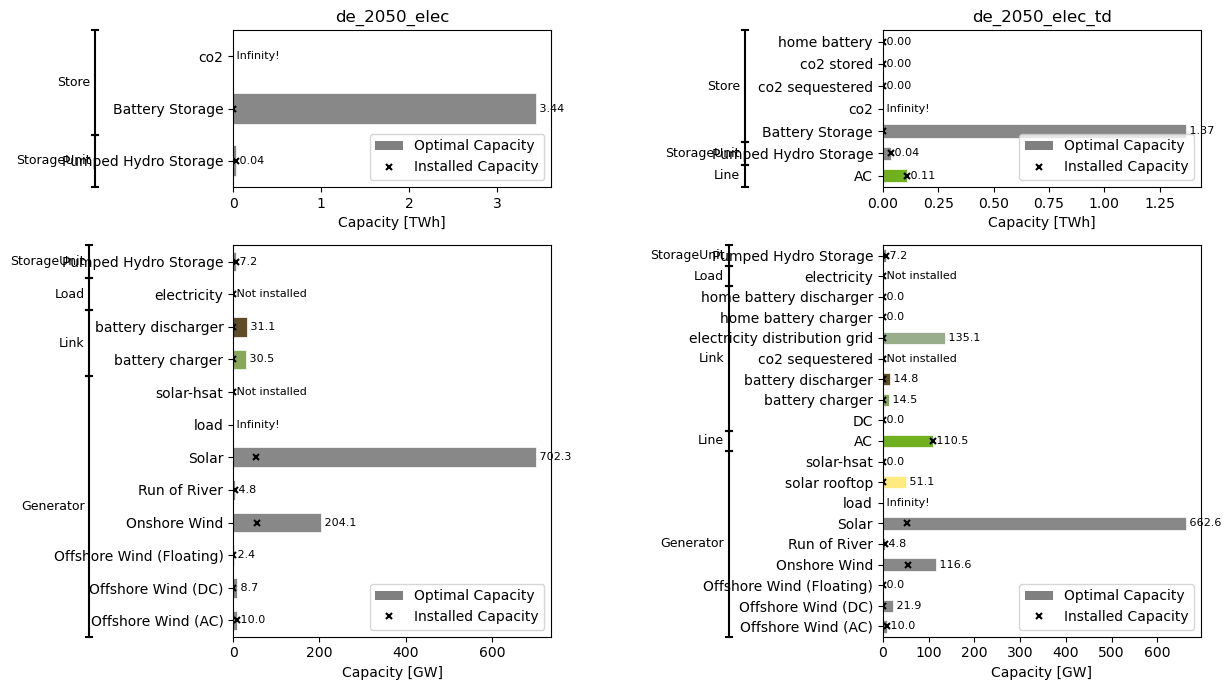

In [156]:
# need to remove load shedding from here
# why same amount of wind/solar in this graph but not in statistics??
fig, ax = plt.subplots(2, 2, figsize=(13, 7), gridspec_kw={"height_ratios": [2, 5]})

capacity_data = {}

runs = ["de_2050_elec", "de_2050_elec_td"]

for i, run in enumerate(runs):
    max_hours = n[run].storage_units["max_hours"].mean() # to estimate installed storage of StorageUnits
    capacity_data[run] = n[run].statistics()[["Optimal Capacity", "Installed Capacity"]]
    if all(item in capacity_data[run].index for item in ["Link", "Generator", "Load"]):
        df1 = capacity_data[run].drop(["Link", "Generator", "Load"])
    else:
        df1 = capacity_data[run]

    if "StorageUnit" in df1.index:
        df1.loc[("StorageUnit", slice(None)), :] = df1.loc[("StorageUnit", slice(None)), :] * max_hours

    plot_comparison_barh(
        df1 / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2
    )

    if "Store" in capacity_data[run].index:
        df2 = capacity_data[run].drop("Store", level=0)
    else:
        df2 = capacity_data[run]

    plot_comparison_barh(
        df2 / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
    )

plt.tight_layout()
plt.show()

## Mineral intensities

Compare overall mineral usage

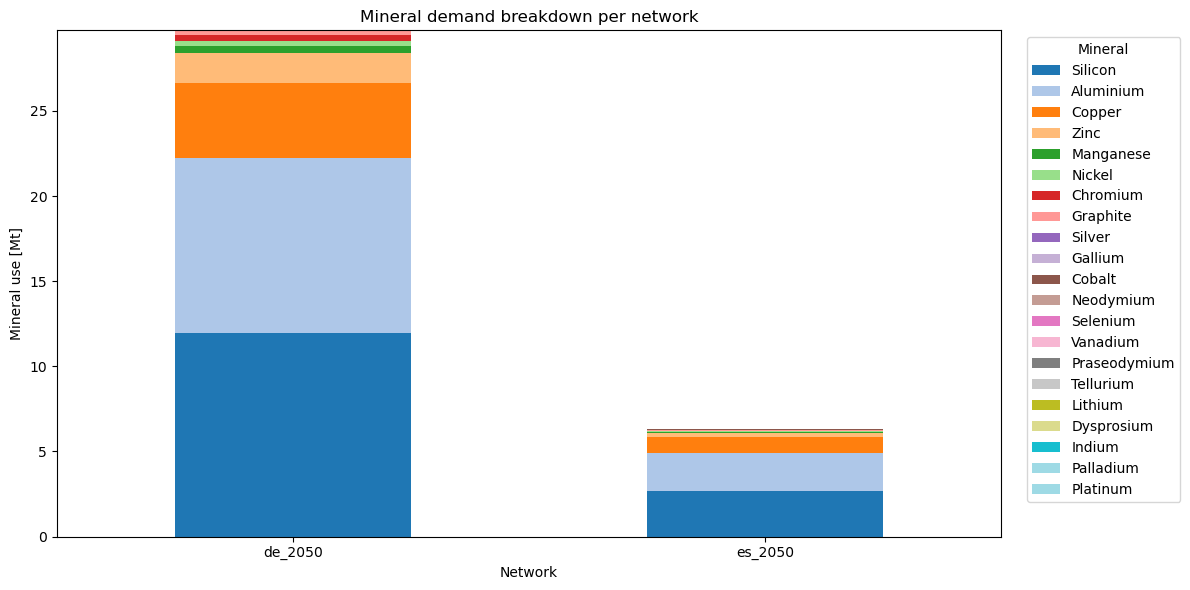

(                de_2050       es_2050
 Silicon       11.942651  2.660012e+00
 Aluminium     10.297131  2.253872e+00
 Copper         4.382722  9.178203e-01
 Zinc           1.802428  2.238351e-01
 Manganese      0.382393  5.983248e-02
 Nickel         0.320957  5.881235e-02
 Chromium       0.314078  5.396015e-02
 Graphite       0.239290  5.329758e-02
 Silver         0.013719  3.055743e-03
 Gallium        0.011588  2.580994e-03
 Cobalt         0.006629  1.476541e-03
 Neodymium      0.007818  1.998551e-04
 Selenium       0.001700  3.785633e-04
 Vanadium       0.001695  3.774696e-04
 Praseodymium   0.001221  3.835069e-05
 Tellurium      0.000970  2.159696e-04
 Lithium        0.000884  1.969903e-04
 Dysprosium     0.000855  1.698851e-05
 Indium         0.000017  3.700978e-06
 Palladium      0.000010  2.246009e-06
 Platinum       0.000003  5.715740e-07,
 {'de_2050':     component             carrier  carrier capacity    PyPSA technology  \
  0   Generator  Offshore Wind (AC)         353.26226

In [ ]:
compare_networks(["de_2050", "es_2050"], n, minerals, tech_scenarios, mineral_intensities)

Compare rare earth usage

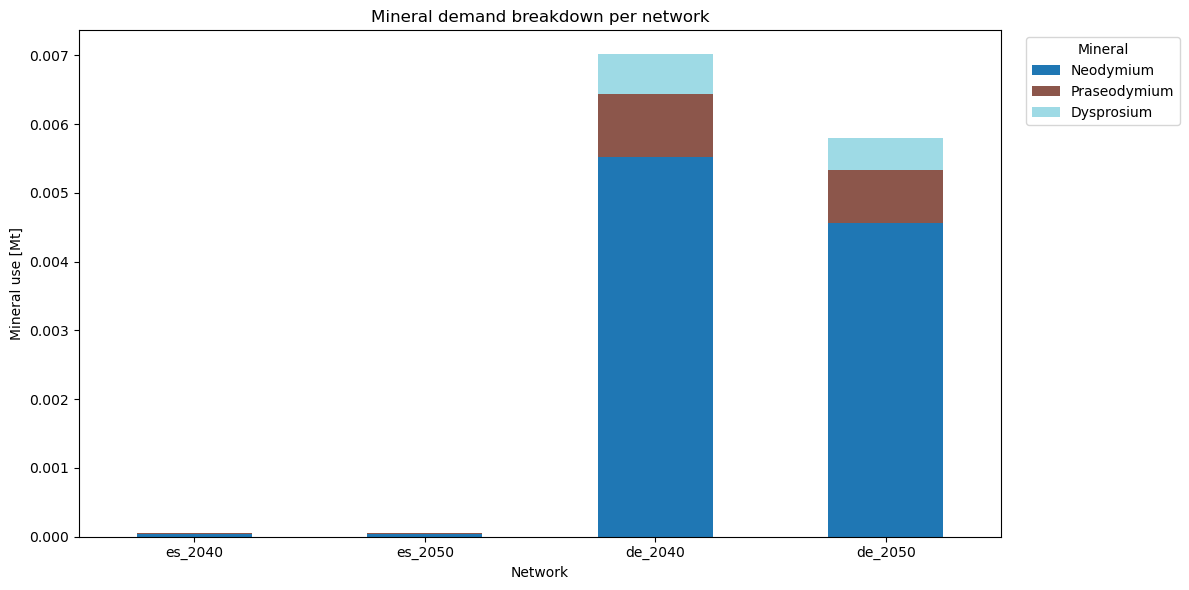

(               es_2040   es_2050   de_2040   de_2050
 Neodymium     0.000036  0.000041  0.005522  0.004560
 Praseodymium  0.000010  0.000011  0.000915  0.000779
 Dysprosium    0.000001  0.000001  0.000577  0.000463,
 {'es_2040':     component             carrier  carrier capacity    PyPSA technology  \
  0   Generator  Offshore Wind (AC)           0.00000  Offshore Wind (AC)   
  1   Generator  Offshore Wind (AC)           0.00000  Offshore Wind (AC)   
  2   Generator  Offshore Wind (AC)           0.00000  Offshore Wind (AC)   
  3   Generator  Offshore Wind (AC)           0.00000  Offshore Wind (AC)   
  4   Generator        Onshore Wind           0.00000        Onshore Wind   
  5   Generator        Onshore Wind           0.00000        Onshore Wind   
  6   Generator        Onshore Wind           0.00000        Onshore Wind   
  7   Generator        Onshore Wind           0.00000        Onshore Wind   
  8   Generator               Solar           0.00000               Solar   
  

In [58]:
compare_networks(["es_2040", sample, "de_2040", "de_2050"], n, rare_earths, tech_scenarios, mineral_intensities)


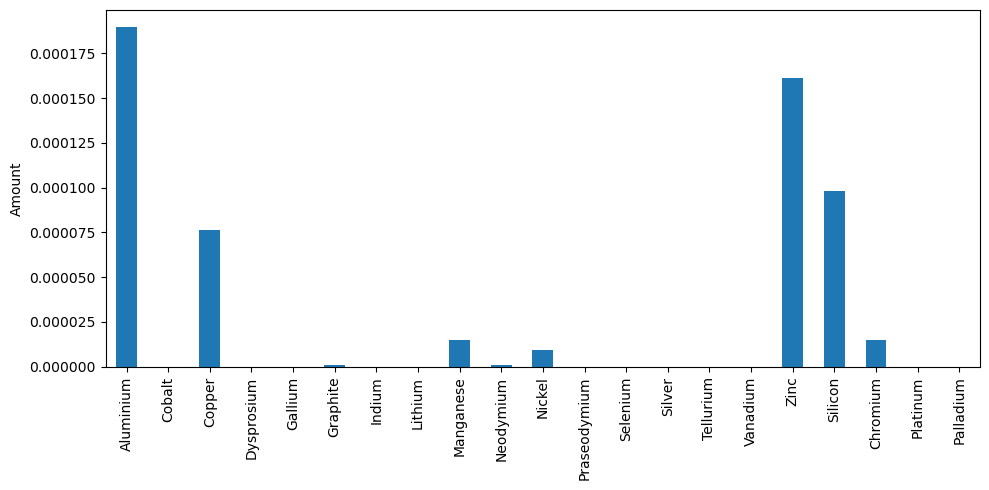

In [32]:
# # get expanded capacities
# expanded_capacities = pd.DataFrame(n[sample].statistics.expanded_capacity().reset_index()).rename(columns={0: 'capacity'})

# # map pypsa technologies to lci technologies
# expanded_capacities["lci_technology"] = expanded_capacities["carrier"].map(techs_map["technology_map"])
# expanded_capacities = pd.merge(expanded_capacities, mineral_intensities, left_on='lci_technology', right_on='Activity', how='inner')

# expanded_capacities[minerals] = expanded_capacities[minerals].mul(expanded_capacities.capacity, axis=0)

s = expanded_capacities[minerals].sum()/(1000*1000*1000)   # example Series, index = mineral names
ax = s.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
plt.tight_layout()
plt.show()

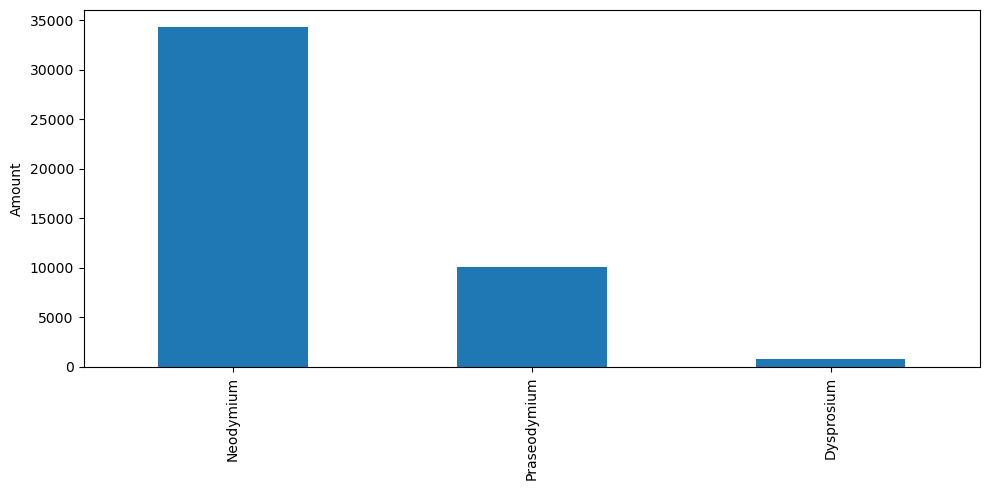

In [114]:
s = expanded_capacities[rare_earths].sum()  # example Series, index = mineral names
ax = s.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
plt.tight_layout()
plt.show()

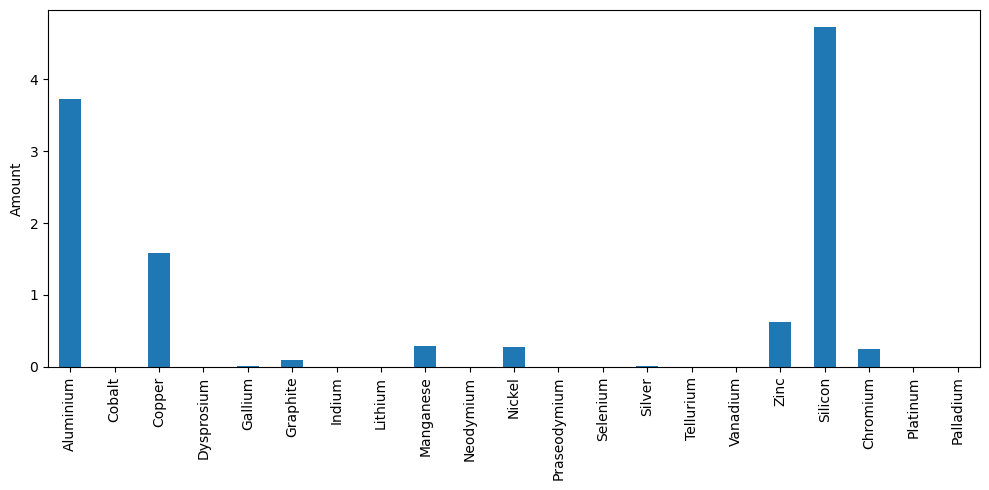

In [109]:
expanded_capacities = pd.DataFrame(n["de_2050"].statistics.expanded_capacity().reset_index()).rename(columns={0: 'capacity'})

expanded_capacities["lci_technology"] = expanded_capacities["carrier"].map(techs_map["technology_map"])
expanded_capacities = pd.merge(expanded_capacities, mineral_intensities, left_on='lci_technology', right_on='Activity', how='inner')

expanded_capacities[minerals] = expanded_capacities[minerals].mul(expanded_capacities.capacity, axis=0)

s = expanded_capacities[minerals].sum()/(1000*1000*1000)   # example Series, index = mineral names
ax = s.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
plt.tight_layout()
plt.show()

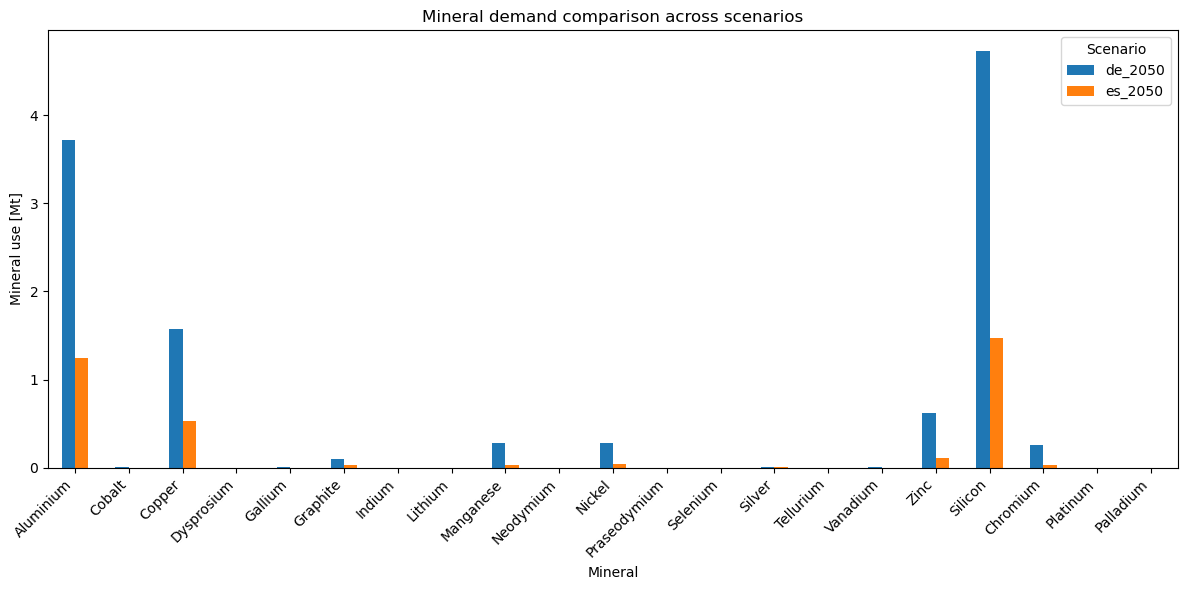

In [7]:
scenarios_to_compare = ["de_2050", "es_2050"]
mineral_data = {}

for scenario_name in scenarios_to_compare:
    expanded_capacities = pd.DataFrame(n[scenario_name].statistics.expanded_capacity().reset_index()).rename(columns={0: 'capacity'})
    
    expanded_capacities["lci_technology"] = expanded_capacities["carrier"].map(techs_map["technology_map"])
    expanded_capacities = pd.merge(expanded_capacities, mineral_intensities, left_on='lci_technology', right_on='Activity', how='inner')
    
    expanded_capacities[minerals] = expanded_capacities[minerals].mul(expanded_capacities.capacity, axis=0)
    
    mineral_data[scenario_name] = expanded_capacities[minerals].sum() / (1000*1000*1000)  # Mt

# Create DataFrame with both scenarios (minerals as rows, scenarios as columns)
comparison_df = pd.DataFrame(mineral_data)

# Plot side-by-side bars
ax = comparison_df.plot.bar(figsize=(12, 6), color=["C0", "C1"])
ax.set_ylabel("Mineral use [Mt]")
ax.set_xlabel("Mineral")
ax.set_title("Mineral demand comparison across scenarios")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Scenario")
plt.tight_layout()
plt.show()

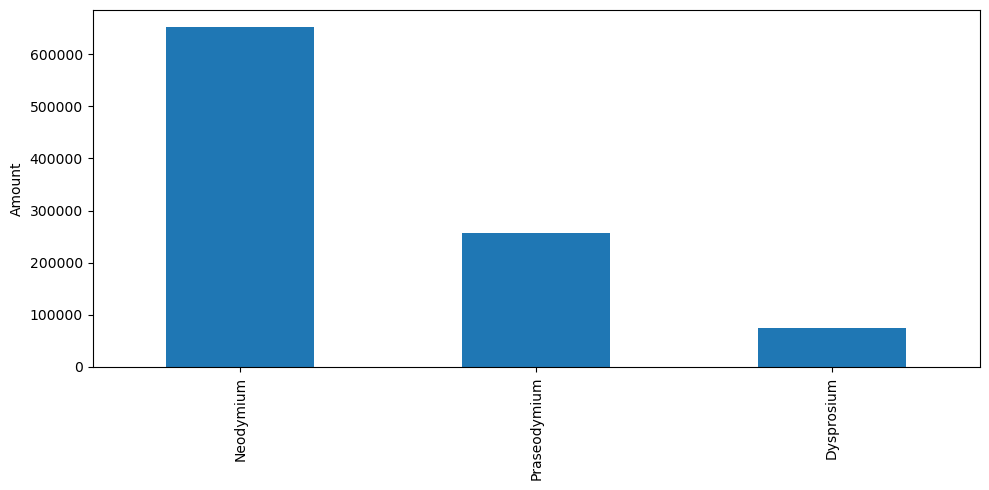

In [112]:
s = expanded_capacities[rare_earths].sum()  # example Series, index = mineral names
ax = s.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
plt.tight_layout()
plt.show()

In [95]:
expanded_capacities

,component,carrier,capacity,lci_technology,Activity,database,Friendly name,Activity long,Unit,Multiplier,...,Nickel,Palladium,Platinum,Praseodymium,Selenium,Silicon,Silver,Tellurium,Vanadium,Zinc
0,Generator,Offshore Wind (AC),0.00000,"wind power plant construction, 2MW, offshore, ...","wind power plant construction, 2MW, offshore, ...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,"Wind, offshore, moving parts (Bonus 2 MW)","wind power plant construction, 2MW, offshore, ...",MW,2.000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-0.000000,0.000000,0.000000e+00
1,Generator,Onshore Wind,0.00000,"wind turbine construction, 4.5MW, onshore","wind turbine construction, 4.5MW, onshore",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,"Wind, onshore (Enercon E112)","wind turbine construction, 4.5MW, onshore (GLO)",MW,4.500,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-0.000000,0.000000,0.000000e+00
2,Generator,Solar,0.00000,"photovoltaic plant construction, 570kWp, multi...","photovoltaic plant construction, 570kWp, multi...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,PV plant - multi-Si,"photovoltaic plant construction, 570kWp, multi...",MW,0.570,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
3,Generator,solar rooftop,73380.40552,"photovoltaic slanted-roof installation, 3kWp, ...","photovoltaic slanted-roof installation, 3kWp, ...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,Rooftop PV - single-Si,"photovoltaic slanted-roof installation, 3kWp, ...",MW,0.003,...,3.197127e+07,1152.015423,300.352898,8778.109657,193667.352914,1.285957e+09,1.509781e+06,-384.919339,150380.786201,9.363962e+07
